# Adversarial Attack Evaluation on MSTAR

Evaluating FGSM and PGD adversarial attacks on a trained ResNet-50 classifier to demonstrate accuracy collapse.

**Attacks:**
- FGSM (Fast Gradient Sign Method) - single-step attack
- PGD (Projected Gradient Descent) - iterative attack (stronger)

**Epsilon values:** 0.01, 0.02, 0.05, 0.10

In [2]:
import os
from pathlib import Path
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import kagglehub

PROJECT_DIR = Path(os.getenv("MSTAR_PROJECT_DIR", Path.cwd())).resolve()
DATA_DIR = Path(os.getenv("MSTAR_DATA_DIR", PROJECT_DIR / "Padded_imgs")).resolve()
CHECKPOINT_DIR = Path(os.getenv("MSTAR_CHECKPOINT_DIR", PROJECT_DIR / "checkpoints")).resolve()
MODEL_CACHE_DIR = Path(os.getenv("MSTAR_MODEL_CACHE_DIR", PROJECT_DIR / ".torch")).resolve()

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)
torch.hub.set_dir(str(MODEL_CACHE_DIR))

# Device: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'CUDA: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'Project directory: {PROJECT_DIR}')
print(f'Data directory: {DATA_DIR}')
print(f'Checkpoint directory: {CHECKPOINT_DIR}')
print(f'Model cache directory: {MODEL_CACHE_DIR}')

CUDA: NVIDIA GeForce RTX 3090
Using device: cuda
Project directory: /workspace/mstar
Data directory: /workspace/mstar/Padded_imgs
Checkpoint directory: /workspace/mstar/checkpoints
Model cache directory: /workspace/mstar/.torch


In [3]:
# Download MSTAR dataset from Kaggle if not present
if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
    print(f'Dataset already exists at {DATA_DIR}')
else:
    print('Downloading MSTAR dataset from Kaggle...')
    try:
        download_path = Path(kagglehub.dataset_download('atreyamajumdar/mstar-dataset-8-classes'))
    except Exception as exc:
        raise RuntimeError(
            'Dataset download failed. Set KAGGLE_USERNAME/KAGGLE_KEY or place kaggle.json in ~/.kaggle/'
        ) from exc

    if (download_path / 'Padded_imgs').exists():
        src = download_path / 'Padded_imgs'
    else:
        src = download_path

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, DATA_DIR, dirs_exist_ok=True)
    print(f'Dataset downloaded to {DATA_DIR}')

print(f'Using dataset directory: {DATA_DIR.resolve()}')

Dataset already exists at /workspace/mstar/Padded_imgs
Using dataset directory: /workspace/mstar/Padded_imgs


In [4]:
# Configuration
BATCH_SIZE = 32
NUM_CLASSES = 8
EPSILON_VALUES = [0.01, 0.02, 0.05, 0.10]

# PGD parameters
PGD_STEPS = 20
PGD_ALPHA = 0.01

NUM_WORKERS = min(4, os.cpu_count() or 2) if device.type == 'cuda' else 0
PIN_MEMORY = device.type == 'cuda'

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(device)
IMAGENET_STD_T = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1).to(device)

# Valid normalized range corresponding to pixel range [0, 1]
NORM_MIN = (0.0 - IMAGENET_MEAN_T) / IMAGENET_STD_T
NORM_MAX = (1.0 - IMAGENET_MEAN_T) / IMAGENET_STD_T

## Load Trained Model and Test Data

In [5]:
# Load model (supports best checkpoint or resume checkpoint)
best_model_path = CHECKPOINT_DIR / 'best_model.pth'
resume_ckpt_path = CHECKPOINT_DIR / 'resume_checkpoint.pth'

dataset_info = None

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

if best_model_path.exists():
    state_dict = torch.load(best_model_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f'Loaded best model: {best_model_path}')
elif resume_ckpt_path.exists():
    resume_ckpt = torch.load(resume_ckpt_path, map_location=device)
    model.load_state_dict(resume_ckpt['model_state_dict'])
    dataset_info = resume_ckpt
    print(f'Loaded model from resume checkpoint: {resume_ckpt_path}')
else:
    raise FileNotFoundError(
        f'No checkpoint found in {CHECKPOINT_DIR}. Expected best_model.pth or resume_checkpoint.pth'
    )

model = model.to(device)
model.eval()
print('Model ready for evaluation')

Loaded best model: /workspace/mstar/checkpoints/best_model.pth
Model ready for evaluation


In [6]:
# test set indices (with fallbacks)
if dataset_info is None:
    dataset_info_path = CHECKPOINT_DIR / 'dataset_info.pth'
    if dataset_info_path.exists():
        dataset_info = torch.load(dataset_info_path, map_location='cpu')
        print(f'Loaded dataset split info: {dataset_info_path}')

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = full_dataset.classes

if dataset_info is not None and 'test_indices' in dataset_info:
    test_indices = dataset_info['test_indices']
    if 'class_names' in dataset_info:
        class_names = dataset_info['class_names']
    print('Using saved test split indices from training run')
else:
    # we're in trouble...recreate split in training notebook
    n_total = len(full_dataset)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val
    _, _, test_subset = random_split(
        full_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42),
    )
    test_indices = test_subset.indices
    print('dataset_info/test_indices not found, recreated test split via seed=42')

test_dataset = Subset(full_dataset, test_indices)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f'Test set: {len(test_dataset)} images')
print(f'Classes: {class_names}')

Loaded dataset split info: /workspace/mstar/checkpoints/dataset_info.pth
Using saved test split indices from training run
Test set: 1421 images
Classes: ['2S1', 'BRDM_2', 'BTR_60', 'D7', 'SLICY', 'T62', 'ZIL131', 'ZSU_23_4']


## Adversarial Attack Functions

In [7]:
def fgsm_attack(model, images, labels, epsilon):
    adv = images.clone().detach().requires_grad_(True)

    outputs = model(adv)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad(set_to_none=True)
    loss.backward()

    # pixel-space epsilon to normalized-space epsilon per channel
    eps_norm = epsilon / IMAGENET_STD_T
    adv = adv + eps_norm * adv.grad.sign()

    # normalszed tensor within valid image range
    adv = torch.max(torch.min(adv, NORM_MAX), NORM_MIN)
    return adv.detach()


def pgd_attack(model, images, labels, epsilon, alpha=0.01, steps=20):
    orig = images.clone().detach()
    adv = orig.clone().detach()

    eps_norm = epsilon / IMAGENET_STD_T
    alpha_norm = alpha / IMAGENET_STD_T

    for _ in range(steps):
        adv.requires_grad_(True)

        outputs = model(adv)
        loss = F.cross_entropy(outputs, labels)
        grad = torch.autograd.grad(loss, adv)[0]

        adv = adv.detach() + alpha_norm * grad.sign()

        # epsilon-ball around original sample
        delta = torch.clamp(adv - orig, min=-eps_norm, max=eps_norm)
        adv = orig + delta

        # Clamp to valid normalized bounds
        adv = torch.max(torch.min(adv, NORM_MAX), NORM_MIN).detach()

    return adv

In [8]:
def evaluate_clean(model, loader):
    # clean images
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return correct / total


def evaluate_attack(model, loader, attack_fn, epsilon, **kwargs):
    # adversial attacks
    model.eval()
    correct, total = 0, 0
    
    for images, labels in tqdm(loader, desc=f'Attacking (eps={epsilon})', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        adv_images = attack_fn(model, images, labels, epsilon, **kwargs)
        
        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return correct / total

## Run Attack Evaluation

In [9]:
clean_acc = evaluate_clean(model, test_loader)
print(f'Clean Accuracy: {clean_acc:.4f} ({clean_acc*100:.2f}%)')

Clean Accuracy: 0.9993 (99.93%)


In [10]:
# FGSM attack across epsilon values
fgsm_results = {}

for eps in EPSILON_VALUES:
    acc = evaluate_attack(model, test_loader, fgsm_attack, eps)
    fgsm_results[eps] = acc
    print(f'FGSM (eps={eps:.2f}): {acc:.4f} ({acc*100:.2f}%)')

Attacking (eps=0.01):   0%|          | 0/45 [00:00<?, ?it/s]

FGSM (eps=0.01): 0.4771 (47.71%)


Attacking (eps=0.02):   0%|          | 0/45 [00:00<?, ?it/s]

FGSM (eps=0.02): 0.2773 (27.73%)


Attacking (eps=0.05):   0%|          | 0/45 [00:00<?, ?it/s]

FGSM (eps=0.05): 0.2519 (25.19%)


Attacking (eps=0.1):   0%|          | 0/45 [00:00<?, ?it/s]

FGSM (eps=0.10): 0.1302 (13.02%)


In [11]:
# PGD attack across epsilon values
pgd_results = {}

for eps in EPSILON_VALUES:
    acc = evaluate_attack(model, test_loader, pgd_attack, eps, alpha=PGD_ALPHA, steps=PGD_STEPS)
    pgd_results[eps] = acc
    print(f'PGD (eps={eps:.2f}): {acc:.4f} ({acc*100:.2f}%)')

Attacking (eps=0.01):   0%|          | 0/45 [00:00<?, ?it/s]

PGD (eps=0.01): 0.0169 (1.69%)


Attacking (eps=0.02):   0%|          | 0/45 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c7b731a200>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  ^<function _MultiProcessingDataLoaderIter.__del__ at 0x79c7b731a200>^
^Traceback (most recent call last):
^^  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^     ^if w.is_alive():

  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process' 
      ^ ^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^
^

PGD (eps=0.02): 0.0028 (0.28%)


Attacking (eps=0.05):   0%|          | 0/45 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c7b731a200><function _MultiProcessingDataLoaderIter.__del__ at 0x79c7b731a200>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        Exception ignored in: if w.is_alive():if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x79c7b731a200>


  Traceback (most recent call last):
    File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 170

PGD (eps=0.05): 0.0028 (0.28%)


Attacking (eps=0.1):   0%|          | 0/45 [00:00<?, ?it/s]

PGD (eps=0.10): 0.0028 (0.28%)


## Results Summary

In [25]:
results_data = []

results_data.append({'Attack': 'None', 'Epsilon': 0.0, 'Accuracy': clean_acc})

for eps, acc in fgsm_results.items():
    results_data.append({'Attack': 'FGSM', 'Epsilon': eps, 'Accuracy': acc})

for eps, acc in pgd_results.items():
    results_data.append({'Attack': 'PGD', 'Epsilon': eps, 'Accuracy': acc})

results_df = pd.DataFrame(results_data)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2)

print(results_df.to_string(index=False))

Attack  Epsilon  Accuracy  Accuracy %
  None     0.00  0.999296       99.93
  FGSM     0.01  0.477129       47.71
  FGSM     0.02  0.277270       27.73
  FGSM     0.05  0.251935       25.19
  FGSM     0.10  0.130190       13.02
   PGD     0.01  0.016890        1.69
   PGD     0.02  0.002815        0.28
   PGD     0.05  0.002815        0.28
   PGD     0.10  0.002815        0.28


In [13]:
# Pivot table for comparison
pivot_df = results_df.pivot(index='Epsilon', columns='Attack', values='Accuracy %')
pivot_df = pivot_df[['None', 'FGSM', 'PGD']].fillna('')
print('\nAccuracy by Attack and Epsilon:')
print(pivot_df.to_string())


Accuracy by Attack and Epsilon:
Attack    None   FGSM   PGD
Epsilon                    
0.00     99.93             
0.01            47.71  1.69
0.02            27.73  0.28
0.05            25.19  0.28
0.10            13.02  0.28


## Accuracy Collapse Curves

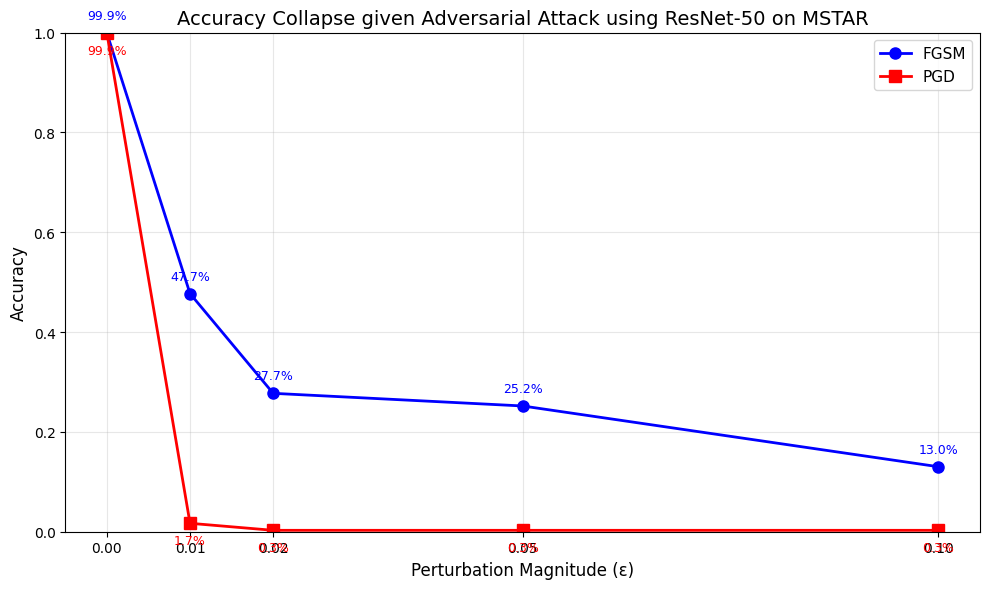

In [20]:
plt.figure(figsize=(10, 6))

epsilons = [0.0] + EPSILON_VALUES

fgsm_accs = [clean_acc] + [fgsm_results[e] for e in EPSILON_VALUES]
plt.plot(epsilons, fgsm_accs, 'b-o', linewidth=2, markersize=8, label='FGSM')

pgd_accs = [clean_acc] + [pgd_results[e] for e in EPSILON_VALUES]
plt.plot(epsilons, pgd_accs, 'r-s', linewidth=2, markersize=8, label='PGD')

plt.xlabel('Perturbation Magnitude (ε)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Collapse given Adversarial Attack using ResNet-50 on MSTAR', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.xticks(epsilons)

for i, (f_acc, p_acc) in enumerate(zip(fgsm_accs, pgd_accs)):
    plt.annotate(f'{f_acc:.1%}', (epsilons[i], f_acc), textcoords='offset points', 
                 xytext=(0, 10), ha='center', fontsize=9, color='blue')
    plt.annotate(f'{p_acc:.1%}', (epsilons[i], p_acc), textcoords='offset points', 
                 xytext=(0, -15), ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('accuracy_collapse.png', dpi=150, bbox_inches='tight')
plt.show()

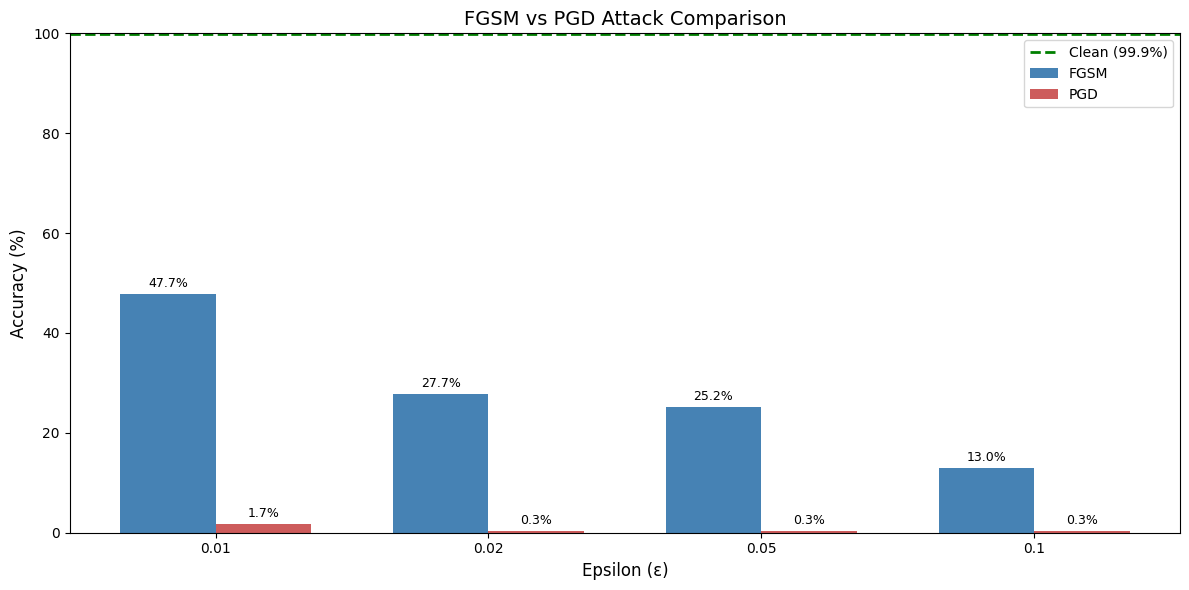

In [15]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(EPSILON_VALUES))
width = 0.35

fgsm_bars = [fgsm_results[e] * 100 for e in EPSILON_VALUES]
pgd_bars = [pgd_results[e] * 100 for e in EPSILON_VALUES]

bars1 = ax.bar(x - width/2, fgsm_bars, width, label='FGSM', color='steelblue')
bars2 = ax.bar(x + width/2, pgd_bars, width, label='PGD', color='indianred')

ax.axhline(y=clean_acc * 100, color='green', linestyle='--', linewidth=2, label=f'Clean ({clean_acc:.1%})')

ax.set_xlabel('Epsilon (ε)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('FGSM vs PGD Attack Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([str(e) for e in EPSILON_VALUES])
ax.legend()
ax.set_ylim(0, 100)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualize Adversarial Examples

In [16]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean


images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

n_samples = 4
sample_images = images[:n_samples]
sample_labels = labels[:n_samples]

eps = 0.05
fgsm_images = fgsm_attack(model, sample_images, sample_labels, eps)
pgd_images = pgd_attack(model, sample_images, sample_labels, eps, alpha=PGD_ALPHA, steps=PGD_STEPS)

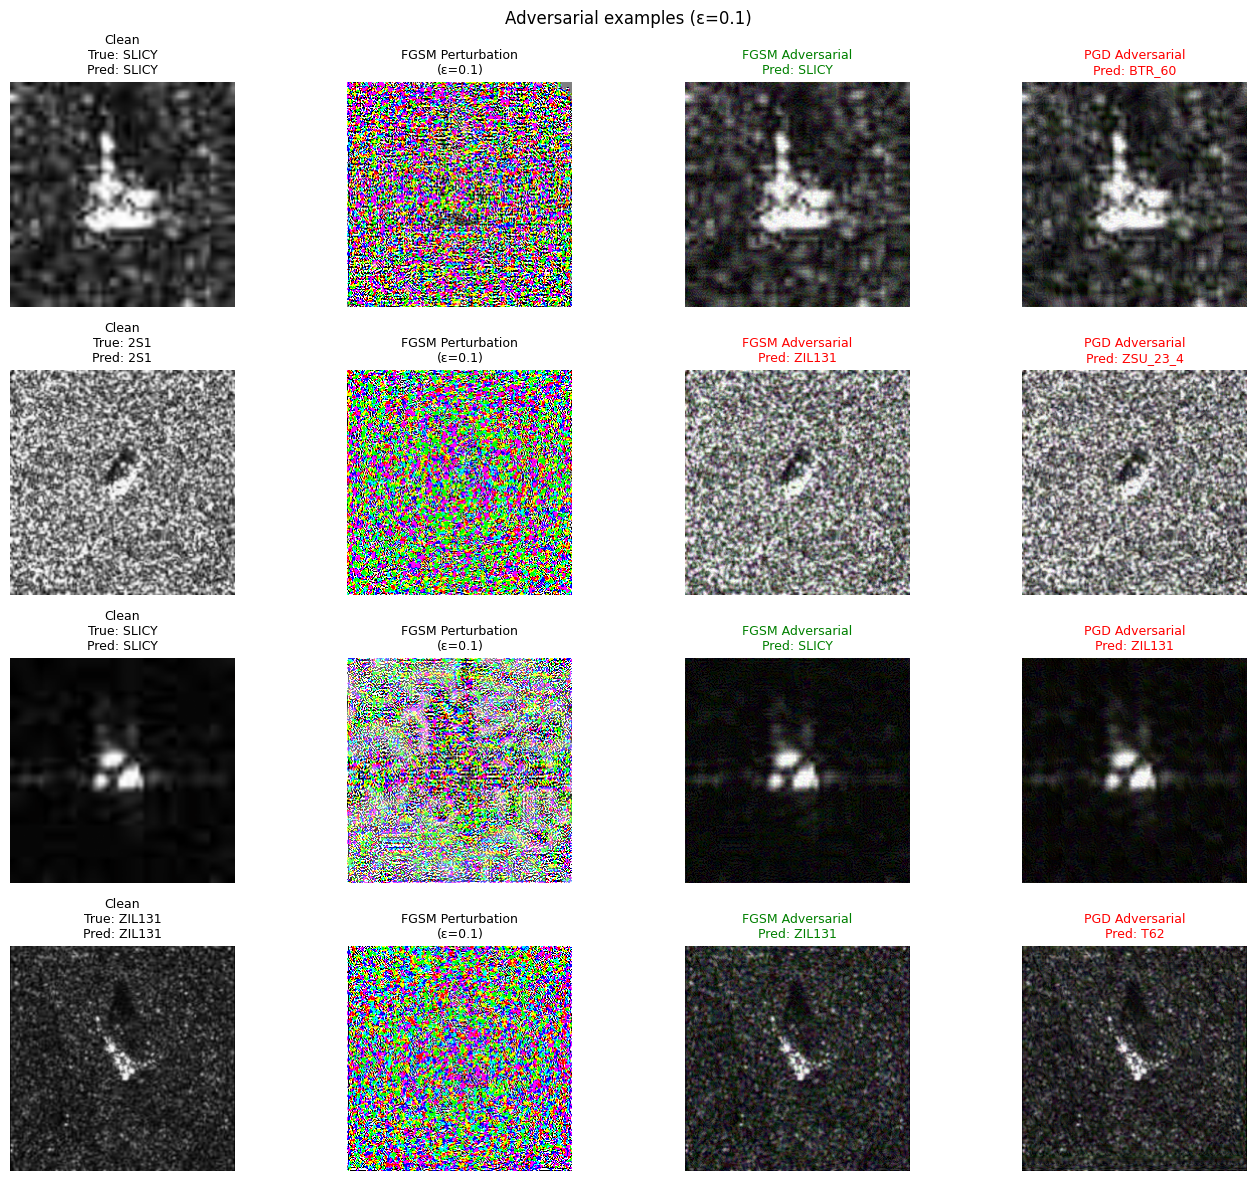

In [21]:
fig, axes = plt.subplots(n_samples, 4, figsize=(14, 12))

for i in range(n_samples):
    clean_img = denormalize(sample_images[i]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i, 0].imshow(clean_img)
    
    with torch.no_grad():
        clean_pred = model(sample_images[i:i+1]).argmax(1).item()
        fgsm_pred = model(fgsm_images[i:i+1]).argmax(1).item()
        pgd_pred = model(pgd_images[i:i+1]).argmax(1).item()
    
    true_label = class_names[sample_labels[i].item()]
    axes[i, 0].set_title(f'Clean\nTrue: {true_label}\nPred: {class_names[clean_pred]}', fontsize=9)
    
    fgsm_pert = (fgsm_images[i] - sample_images[i]).cpu().permute(1, 2, 0).numpy()
    fgsm_pert = (fgsm_pert - fgsm_pert.min()) / (fgsm_pert.max() - fgsm_pert.min() + 1e-8)
    axes[i, 1].imshow(fgsm_pert)
    axes[i, 1].set_title(f'FGSM Perturbation\n(ε={eps})', fontsize=9)
    
    fgsm_img = denormalize(fgsm_images[i]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i, 2].imshow(fgsm_img)
    color = 'green' if fgsm_pred == sample_labels[i].item() else 'red'
    axes[i, 2].set_title(f'FGSM Adversarial\nPred: {class_names[fgsm_pred]}', fontsize=9, color=color)
    
    pgd_img = denormalize(pgd_images[i]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i, 3].imshow(pgd_img)
    color = 'green' if pgd_pred == sample_labels[i].item() else 'red'
    axes[i, 3].set_title(f'PGD Adversarial\nPred: {class_names[pgd_pred]}', fontsize=9, color=color)
    
    for j in range(4):
        axes[i, j].axis('off')

plt.suptitle(f'Adversarial examples (ε={eps})', fontsize=12)
plt.tight_layout()
plt.savefig('adversarial_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Results

In [22]:
results_df.to_csv('attack_results.csv', index=False)
print('Results saved to attack_results.csv')

print(f'Clean Accuracy: {clean_acc:.2%}')
print(f'\nFGSM Accuracy Drop (ε=0.10): {clean_acc - fgsm_results[0.10]:.2%}')
print(f'PGD Accuracy Drop (ε=0.10): {clean_acc - pgd_results[0.10]:.2%}')
print(f'\nPGD is {((clean_acc - pgd_results[0.10]) / (clean_acc - fgsm_results[0.10]) - 1) * 100:.1f}% more effective than FGSM at ε=0.10')

Results saved to attack_results.csv
Clean Accuracy: 99.93%

FGSM Accuracy Drop (ε=0.10): 86.91%
PGD Accuracy Drop (ε=0.10): 99.65%

PGD is 14.7% more effective than FGSM at ε=0.10


In [24]:
print('| Attack | ε     | Accuracy | Drop from Clean |')
print('|--------|-------|----------|-----------------|')
print(f'| Clean  | 0.00  | {clean_acc:.2%}   | -               |')
for eps in EPSILON_VALUES:
    fgsm_drop = clean_acc - fgsm_results[eps]
    print(f'| FGSM   | {eps:.2f}  | {fgsm_results[eps]:.2%}   | -{fgsm_drop:.2%}          |')
for eps in EPSILON_VALUES:
    pgd_drop = clean_acc - pgd_results[eps]
    print(f'| PGD    | {eps:.2f}  | {pgd_results[eps]:.2%}   | -{pgd_drop:.2%}          |')

| Attack | ε     | Accuracy | Drop from Clean |
|--------|-------|----------|-----------------|
| Clean  | 0.00  | 99.93%   | -               |
| FGSM   | 0.01  | 47.71%   | -52.22%          |
| FGSM   | 0.02  | 27.73%   | -72.20%          |
| FGSM   | 0.05  | 25.19%   | -74.74%          |
| FGSM   | 0.10  | 13.02%   | -86.91%          |
| PGD    | 0.01  | 1.69%   | -98.24%          |
| PGD    | 0.02  | 0.28%   | -99.65%          |
| PGD    | 0.05  | 0.28%   | -99.65%          |
| PGD    | 0.10  | 0.28%   | -99.65%          |
